# Discovery Notebook - PEAD Data Exploration

Helper functions for calculating CAR, loading data, and examining single-stock behavior around earnings announcement dates.


In [16]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
from typing import Optional, Tuple
import matplotlib.pyplot as plt

%matplotlib inline

# Config
DB_FILE = Path("db.h5")
H5_STOCKS = "sp400"
H5_EARNINGS = "earnings"
H5_MACRO = "macros"
IJH_TICKER = "IJH"

## 1. Loading Helpers

In [5]:
def load_ticker(ticker: str, start: str = None, end: str = None) -> pd.DataFrame:
    """
    Load historical OHLCV for a single ticker from the local HDF5 database.
    
    Args:
        ticker: Stock ticker (e.g., 'AAPL')
        start:  Optional start date ('YYYY-MM-DD')
        end:    Optional end date ('YYYY-MM-DD')
    """
    path = f"/{H5_STOCKS}/{ticker}"
    df = pd.read_hdf(DB_FILE, path)
    
    if start:
        df = df[df["Date"] >= pd.to_datetime(start)]
    if end:
        df = df[df["Date"] <= pd.to_datetime(end)]
    
    return df.sort_values("Date").reset_index(drop=True)

def load_ijh(start: str = None, end: str = None) -> pd.DataFrame:
    """Load IJH (S&P Mid-Cap 400 ETF) benchmark data."""
    path = f"/{H5_MACRO}/{IJH_TICKER}"
    df = pd.read_hdf(DB_FILE, path)
    
    if start:
        df = df[df["Date"] >= pd.to_datetime(start)]
    if end:
        df = df[df["Date"] <= pd.to_datetime(end)]
    
    return df.sort_values("Date").reset_index(drop=True)

def get_ticker_list() -> list:
    """Return all tickers stored in the sp400 group."""
    with pd.HDFStore(DB_FILE, mode="r") as store:
        keys = store.keys()
    return sorted([k.split("/")[-1] for k in keys if f"/{H5_STOCKS}/" in k])

## 2. Calculate Log Returns & CAR

In [6]:
def calc_log_return(df: pd.DataFrame, price_col: str = "Close") -> pd.Series:
    """Daily log returns: ln(Price_t / Price_{t-1})"""
    prices = df[price_col]
    return np.log(prices / prices.shift(1))

def calc_abnormal_return(stock_df: pd.DataFrame, ijh_df: pd.DataFrame) -> pd.Series:
    """
    Abnormal returns: AR = ln(Stock_t/Stock_{t-1}) - ln(IJH_t/IJH_{t-1})
    """
    stock_ret = calc_log_return(stock_df)
    ijh_ret = calc_log_return(ijh_df)
    return stock_ret - ijh_ret

def calc_car(stock_df: pd.DataFrame, ijh_df: pd.DataFrame, 
             event_date: str, horizon_days: int = 10) -> float:
    """
    Cumulative Abnormal Return (CAR) from T+1 to T+horizon_days.
    
    Args:
        stock_df:      Stock price DataFrame
        ijh_df:        IJH benchmark DataFrame
        event_date:    Announcement date ('YYYY-MM-DD')
        horizon_days:  Holding period (default 10 for T+1 to T+11)
    """
    merged = pd.merge(stock_df, ijh_df, on="Date", suffixes=('_stock', '_ijh'))
    merged = merged.sort_values("Date").reset_index(drop=True)
    
    merged["ar"] = calc_abnormal_return(
        merged[["Date", "Close_stock"]].rename(columns={"Close_stock": "Close"}),
        merged[["Date", "Close_ijh"]].rename(columns={"Close_ijh": "Close"})
    )
    
    event_dt = pd.to_datetime(event_date)
    post_event = merged[merged["Date"] > event_dt]
    holding_period = post_event.head(horizon_days)
    
    return holding_period["ar"].sum()

In [7]:
def plot_event_window(ticker: str, event_date: str, days_before: int = 5, days_after: int = 10):
    """
    Plot price % change and volume around an event date.

    Args:
        ticker: Stock ticker to analyze
        event_date: Event date in 'YYYY-MM-DD' format
        days_before: Days before event to show (default 5)
        days_after: Days after event to show (default 10)
    """
    # Load data
    stock = load_ticker(ticker)
    ijh = load_ijh()
    event_dt = pd.to_datetime(event_date)

    # Find the index position of the event date in stock data
    stock_event_idx = stock[stock["Date"] >= event_dt].index[0] if any(stock["Date"] >= event_dt) else len(stock) - 1
    ijh_event_idx = ijh[ijh["Date"] >= event_dt].index[0] if any(ijh["Date"] >= event_dt) else len(ijh) - 1

    # Get window
    start_idx = max(0, stock_event_idx - days_before)
    end_idx = min(len(stock) - 1, stock_event_idx + days_after)
    stock_window = stock.iloc[start_idx:end_idx + 1].copy()

    start_idx_ijh = max(0, ijh_event_idx - days_before)
    end_idx_ijh = min(len(ijh) - 1, ijh_event_idx + days_after)
    ijh_window = ijh.iloc[start_idx_ijh:end_idx_ijh + 1].copy()

    # Calculate % change from event date
    stock_event_price = stock_window[stock_window["Date"] >= event_dt]["Close"].iloc[0] if any(stock_window["Date"] >= event_dt) else stock_window["Close"].iloc[-1]
    stock_window["Pct_Change"] = (stock_window["Close"] / stock_event_price - 1) * 100

    ijh_event_price = ijh_window[ijh_window["Date"] >= event_dt]["Close"].iloc[0] if any(ijh_window["Date"] >= event_dt) else ijh_window["Close"].iloc[-1]
    ijh_window["Pct_Change"] = (ijh_window["Close"] / ijh_event_price - 1) * 100

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    # Plot price % change
    ax1.plot(range(len(stock_window)), stock_window["Pct_Change"],
            label=f"{ticker}", linewidth=2, color="blue")
    ax1.plot(range(len(ijh_window)), ijh_window["Pct_Change"],
            label="IJH (S&P Mid-Cap 400)", linewidth=2, color="orange", linestyle="--")

    # Event line
    event_x = stock_window[stock_window["Date"] >= event_dt].index[0] - stock_window.index[0]
    ax1.axvline(x=event_x, color="red", linestyle=":", alpha=0.7, label=f"Event Date({event_date})")
    ax1.axhline(y=0, color="gray", linestyle="-", alpha=0.3)

    ax1.set_ylabel("% Change from Event", fontsize=12)
    ax1.set_title(f"{ticker} vs IJH Event Window ({event_date})", fontsize=14, fontweight="bold")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # Format x-axis
    tick_positions = range(0, len(stock_window), max(1, len(stock_window) // 10))
    tick_labels = [stock_window.iloc[i]["Date"].strftime("%m/%d") for i in tick_positions]
    ax1.set_xticks(tick_positions)
    ax1.set_xticklabels([])

    # Plot volume as bar chart
    ax2.bar(range(len(stock_window)), stock_window["Volume"], color="steelblue", alpha=0.6)
    ax2.axvline(x=event_x, color="red", linestyle=":", alpha=0.7)
    ax2.set_ylabel("Volume", fontsize=12)
    ax2.set_xlabel("Trading Days", fontsize=12)

    # Format x-axis with dates
    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels(tick_labels, rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

    return fig, (ax1, ax2)

# Example usage:
# plot_event_window("AAPL", "2025-01-15")


## Helper to calculate Metrics for verification

In [8]:
# =============================================================================
# 1. PRE-EVENT MOMENTUM (Mom_5D)
# =============================================================================

def calc_momentum_5d(df: pd.DataFrame, event_date: str, price_col: str = "Close") -> float:
    """
    Pre-event momentum: percentage change from T-5 to T.

    Formula: Mom_5D = (Close_T / Close_{T-5}) - 1
    """
    event_dt = pd.to_datetime(event_date)

    # Find closest trading day <= event_date for T
    t_idx = df[df["Date"] <= event_dt].index[-1]

    # T-5
    t_minus_5_idx = max(0, t_idx - 5)

    close_t = df.loc[t_idx, price_col]
    close_t_5 = df.loc[t_minus_5_idx, price_col]

    return (close_t / close_t_5) - 1


# =============================================================================
# 2. CUMULATIVE ABNORMAL RETURN (CAR)
# =============================================================================

def calc_car(stock_df: pd.DataFrame, index_df: pd.DataFrame,
            event_date: str, hold_days: int = 10) -> float:
    """
    Cumulative Abnormal Return over T+1 to T+hold_days.

    Formula: CAR = sum[ ln(Stock_t/Stock_{t-1}) - ln(Index_t/Index_{t-1}) ]
    """
    event_dt = pd.to_datetime(event_date)

    # Get T index in stock data
    t_stock_idx = stock_df[stock_df["Date"] <= event_dt].index[-1]

    # Holding period: T+1 to T+hold_days
    start_idx = t_stock_idx + 1
    end_idx = min(start_idx + hold_days, len(stock_df) - 1)
    stock_hold = stock_df.iloc[start_idx:end_idx].copy().reset_index(drop=True)

    # Get corresponding index period
    t_index_idx = index_df[index_df["Date"] <= event_dt].index[-1]
    idx_start = t_index_idx + 1
    idx_end = min(idx_start + hold_days, len(index_df) - 1)
    idx_hold = index_df.iloc[idx_start:idx_end].copy().reset_index(drop=True)

    # Log returns
    stock_log_ret = np.log(stock_hold["Close"] / stock_hold["Close"].shift(1))
    idx_log_ret = np.log(idx_hold["Close"] / idx_hold["Close"].shift(1))

    # Sum abnormal returns
    car = (stock_log_ret - idx_log_ret).sum()

    return car


# =============================================================================
# 3. MARKET-ADJUSTED MAXIMUM DRAWDOWN (MaxDD_MA)
# =============================================================================

def calc_maxdd_ma(stock_df: pd.DataFrame, index_df: pd.DataFrame,
                    event_date: str, hold_days: int = 10) -> float:
    """
    Worst market-adjusted drawdown during holding period.

    Formula: MaxDD_MA = min[ (Stock_t/Stock_T - 1) - (Index_t/Index_T - 1) ]
    """
    event_dt = pd.to_datetime(event_date)

    # T (event day) prices
    t_stock_idx = stock_df[stock_df["Date"] <= event_dt].index[-1]
    t_index_idx = index_df[index_df["Date"] <= event_dt].index[-1]

    price_stock_t = stock_df.loc[t_stock_idx, "Close"]
    price_index_t = index_df.loc[t_index_idx, "Close"]

    # Holding period
    start_stock = t_stock_idx + 1
    end_stock = min(start_stock + hold_days, len(stock_df) - 1)
    stock_hold = stock_df.iloc[start_stock:end_stock].copy()

    start_idx = t_index_idx + 1
    end_idx = min(start_idx + hold_days, len(index_df) - 1)
    idx_hold = index_df.iloc[start_idx:end_idx].copy()

    # Percentage change from T
    stock_pct = (stock_hold["Close"].values / price_stock_t) - 1
    idx_pct = (idx_hold["Close"].values / price_index_t) - 1

    # Market-adjusted path
    ma_path = stock_pct - idx_pct

    return ma_path.min()


# =============================================================================
# 4. VOLUME FOOTPRINT (Gate 2)
# =============================================================================

def calc_volume_ratio(stock_df: pd.DataFrame, event_date: str,
                        ma_window: int = 20, event_window: int = 3) -> float:
    """
    Compare event-period volume to rolling average.

    Formula: (Volume_T + Volume_{T+1} + Volume_{T+2}) / 3  >  2.0 × Rolling 20D MA
    Returns the ratio (not boolean).
    """
    event_dt = pd.to_datetime(event_date)
    t_idx = stock_df[stock_df["Date"] <= event_dt].index[-1]

    # Event window volume average (T to T+2)
    end_event_idx = min(t_idx + event_window, len(stock_df) - 1)
    event_volume = stock_df.iloc[t_idx:end_event_idx + 1]["Volume"].mean()

    # Rolling 20-day volume average (before event)
    start_ma_idx = max(0, t_idx - ma_window)
    ma_volume = stock_df.iloc[start_ma_idx:t_idx]["Volume"].mean()

    return event_volume / ma_volume if ma_volume > 0 else 0.0


# =============================================================================
# 5. VERIFICATION GATE COMBINED
# =============================================================================

def verify_pead_event(stock_df: pd.DataFrame, index_df: pd.DataFrame,
                    event_date: str, hold_days: int = 10) -> dict:
    """
    Run all 3 verification gates on a single event.

    Returns dict with all metrics and boolean pass/fail for each gate.
    """
    car = calc_car(stock_df, index_df, event_date, hold_days)
    maxdd = calc_maxdd_ma(stock_df, index_df, event_date, hold_days)
    vol_ratio = calc_volume_ratio(stock_df, event_date)

    # Gate conditions
    gate1 = car > 0.03
    gate2 = vol_ratio > 2.0
    gate3 = maxdd > -0.015

    return {
        "event_date": event_date,
        "car": car,
        "maxdd_ma": maxdd,
        "volume_ratio": vol_ratio,
        "gate1_pass": gate1,
        "gate2_pass": gate2,
        "gate3_pass": gate3,
        "is_true_pead": gate1 and gate2 and gate3,
    }


## 3. Exploration

In [9]:
# List available tickers
tickers = get_ticker_list()
print(f"Tickers in database: {len(tickers)}")
print(f"Sample: {', '.join(tickers[:5])}")

Tickers in database: 399
Sample: AA, AAL, AAON, ACI, ACM


In [10]:
# Load a specific stock
# ticker = tickers[0] if tickers else "AA"
ticker = 'BWA'
df = load_ticker(ticker)
ijh = load_ijh()

print(f"{ticker} - {len(df)} rows, {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"IJH    - {len(ijh)} rows,  {ijh['Date'].min().date()} to {ijh['Date'].max().date()}")

df.head()

BWA - 3769 rows, 2011-06-16 to 2026-06-11
IJH    - 3769 rows,  2011-06-17 to 2026-06-12


,Date,Open,High,Low,Close,Volume
0,2011-06-16,25.470847,25.943479,25.111793,25.426881,2466710
1,2011-06-17,25.895849,26.580983,25.507485,26.203610,4696451
2,2011-06-20,26.115678,26.921718,25.950806,26.811803,3560905
3,2011-06-21,26.998658,27.844999,26.910726,27.683791,4165939
4,2011-06-22,27.625170,27.982759,27.496937,27.559221,2987680


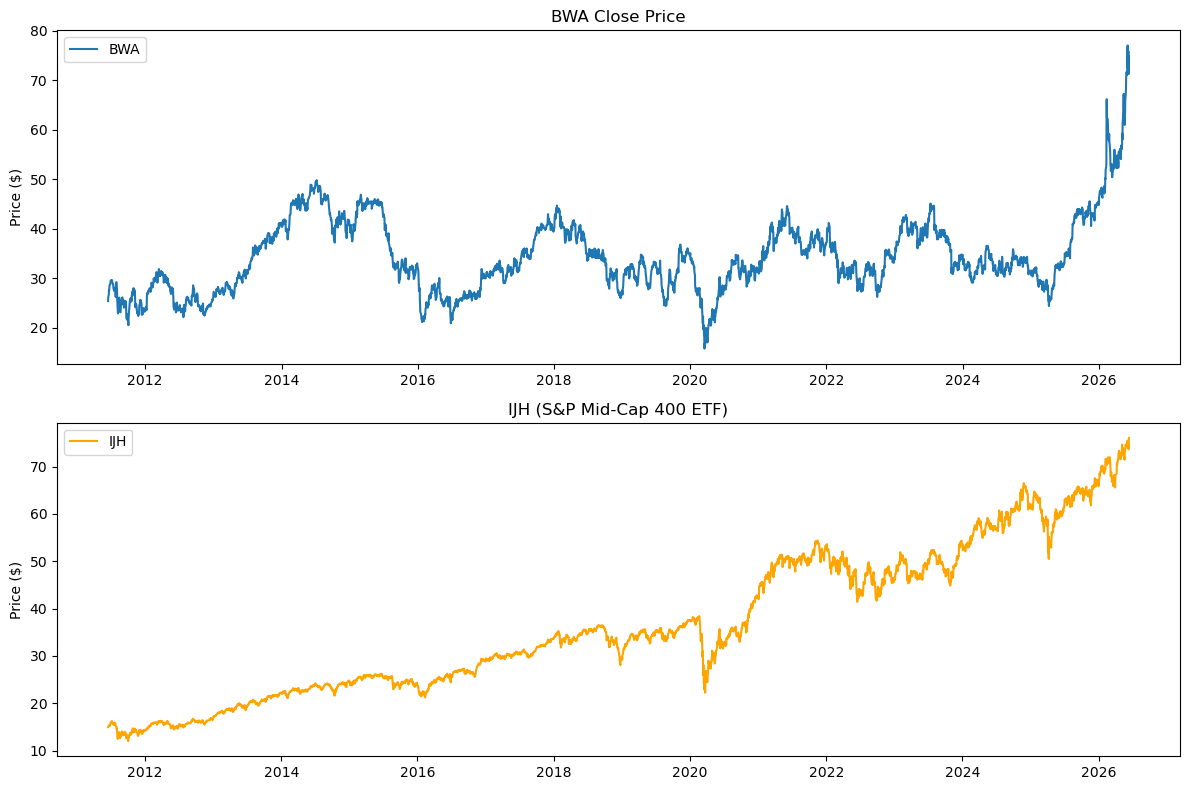

In [11]:
# Plot price history
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax1 = axes[0]
ax1.plot(df["Date"], df["Close"], label=ticker)
ax1.set_title(f"{ticker} Close Price")
ax1.set_ylabel("Price ($)")
ax1.legend()

ax2 = axes[1]
ax2.plot(ijh["Date"], ijh["Close"], label="IJH", color="orange")
ax2.set_title("IJH (S&P Mid-Cap 400 ETF)")
ax2.set_ylabel("Price ($)")
ax2.legend()

plt.tight_layout()
plt.show()

## 4. CAR Calculation Example

In [12]:
# Example: Assume earnings announced on Jan 15, 2025 for a stock
# We want CAR from T+1 (Jan 16) to T+11 (Jan 29)

event_date = "2025-01-15"

try:
    car = calc_car(df, ijh, event_date, horizon_days=10)
    print(f"CAR for {ticker} (event={event_date}, 10-day): {car:.4%}")
except Exception as e:
    print(f"Error: {e}")

Error: calc_car() got an unexpected keyword argument 'horizon_days'


## 5. Rolling CAR Analysis

Calculate CAR for multiple date windows to see how the stock behaves.

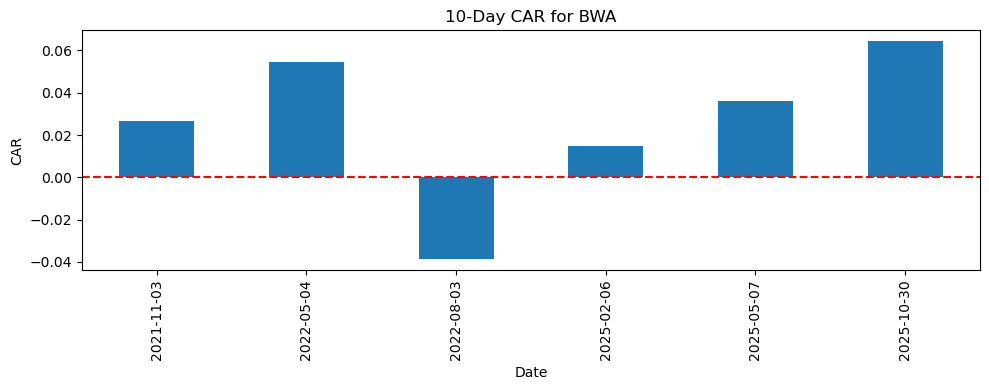

In [13]:
# Pick random dates or specific dates for CAR analysis
# test_dates = [
#     "2024-01-15",
#     "2024-04-15",
#     "2024-07-15",
#     "2024-10-15",
#     "2025-01-15",
# ]
test_dates = [
    '2021-11-03',
    '2022-05-04',
    '2022-08-03',
    '2025-02-06',
    '2025-05-07',
    '2025-10-30'
]

results = []
for date in test_dates:
    try:
        car_val = calc_car(df, ijh, date)
        results.append({"Date": date, "CAR": car_val})
    except Exception:
        pass

results_df = pd.DataFrame(results)
results_df.set_index("Date")["CAR"].plot(kind="bar", figsize=(10, 4))
plt.axhline(0, color="red", linestyle="--")
plt.title(f"10-Day CAR for {ticker}")
plt.ylabel("CAR")
plt.tight_layout()
plt.show()

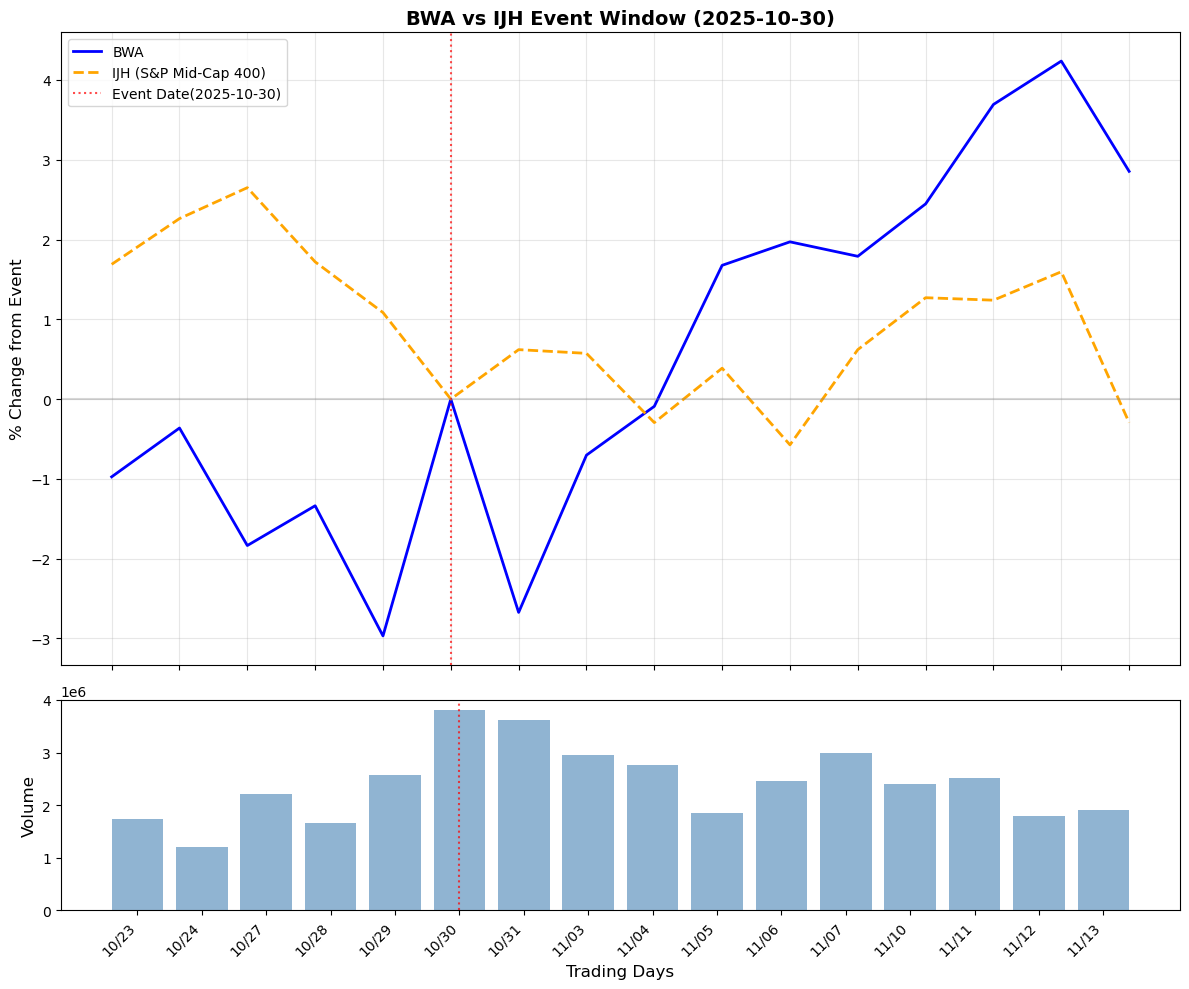

(<Figure size 1200x1000 with 2 Axes>,
 (<Axes: title={'center': 'BWA vs IJH Event Window (2025-10-30)'}, ylabel='% Change from Event'>,
  <Axes: xlabel='Trading Days', ylabel='Volume'>))

In [14]:
plot_event_window(ticker, "2025-10-30")

## Verification

In [15]:
# Load data
stock = load_ticker("AA", "2024-01-01", "2025-06-30")
ijh = load_ijh("2024-01-01", "2025-06-30")

# Single event verification
result = verify_pead_event(stock, ijh, "2024-04-15")
result


{'event_date': '2024-04-15',
 'car': 0.022174068710991472,
 'maxdd_ma': -0.02456219876339072,
 'volume_ratio': 1.6336352289650578,
 'gate1_pass': False,
 'gate2_pass': False,
 'gate3_pass': False,
 'is_true_pead': False}

In [17]:
path = f"/{H5_EARNINGS}/calendar"
df = pd.read_hdf(DB_FILE, path)
df

,Date,ticker,eps_estimate,reported_eps
0,2025-07-16 20:12:25,AA,0.38574,0.39
1,2025-10-22 20:10:00,AA,-0.05400,-0.02
2,2026-01-22 21:10:00,AA,1.01012,1.26
3,2026-04-16 20:10:00,AA,1.54816,1.40
4,2025-07-24 11:00:00,AAL,0.77424,0.95
...,...,...,...,...
75,2026-04-27 20:04:00,AMKR,0.24337,0.33
76,2025-07-25 11:00:46,AN,4.70400,5.46
77,2025-10-23 11:06:32,AN,4.83664,5.01
78,2026-02-06 11:59:00,AN,4.87743,5.08


## Gate 1: CAR > 3%

In [23]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

DB_FILE = "db.h5"

# Load data
earnings = pd.read_hdf(DB_FILE, "earnings/calendar")
earnings["Date"] = pd.to_datetime(earnings["Date"])

ijh_full = pd.read_hdf(DB_FILE, "macros/IJH")
ijh_full["Date"] = pd.to_datetime(ijh_full["Date"])
ijh_full = ijh_full.sort_values("Date").reset_index(drop=True)

def calc_car_for_event(row, horizon=10):
    """Calculate CAR for a single earnings event row."""
    ticker = row["ticker"]
    event_dt = row["Date"]

    # Load stock price data
    try:
        stock_full = pd.read_hdf(DB_FILE, f"/sp400/{ticker}")
        stock_full["Date"] = pd.to_datetime(stock_full["Date"])
        stock_full = stock_full.sort_values("Date").reset_index(drop=True)
    except (KeyError, FileNotFoundError):
        return None

    # Find T (event date) index
    t_idx = stock_full[stock_full["Date"] <= event_dt].index
    if len(t_idx) == 0:
        return None
    t_idx = t_idx[-1]

    # Holding period: T+1 to T+horizon
    start = t_idx + 1
    end = start + horizon
    if end > len(stock_full):
        return None
    stock_hold = stock_full.iloc[start:end].reset_index(drop=True)

    # Find same window in IJH
    ijh_t_idx = ijh_full[ijh_full["Date"] <= event_dt].index[-1]
    ijh_start = ijh_t_idx + 1
    ijh_end = ijh_start + horizon
    if ijh_end > len(ijh_full):
        return None
    ijh_hold = ijh_full.iloc[ijh_start:ijh_end].reset_index(drop=True)

    # Calculate log returns
    stock_ret = np.log(stock_hold["Close"] / stock_hold["Close"].shift(1))
    ijh_ret = np.log(ijh_hold["Close"] / ijh_hold["Close"].shift(1))

    # CAR = sum of abnormal returns
    return (stock_ret - ijh_ret).sum()

# Calculate CAR for all events
print("Calculating CAR for each earnings event...")
tqdm.pandas()
earnings["car_10d"] = earnings.apply(calc_car_for_event, axis=1)

# Drop rows where CAR could not be calculated
results = earnings.dropna(subset=["car_10d"]).copy()
results["car_pct"] = results["car_10d"] * 100

print(f"\nEvents analyzed: {len(results)} / {len(earnings)}")
print(f"Success rate:    {len(results)/len(earnings)*100:.1f}%")

# Gate 1: CAR > 3%
gate1_pass = results[results["car_10d"] > 0.03].copy()

print(f"\n{'='*60}")
print(f"  GATE 1 RESULT: CAR > 3.0%")
print(f"{'='*60}")
print(f"  Passing events:  {len(gate1_pass)} / {len(results)}({len(gate1_pass)/len(results)*100:.1f}%)")
print(f"  Mean CAR (all):    {results['car_10d'].mean():.2%}")
print(f"  Mean CAR (gate1):  {gate1_pass['car_10d'].mean():.2%}")
print(f"{'='*60}")

# Distribution stats
print("\n--- CAR Distribution ---")
print(results["car_10d"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# Top 10 positive CAR events
print("\n--- Top 10 Positive CAR ---")
print(results.nlargest(10, "car_10d")[["Date", "ticker", "reported_eps", "eps_estimate",
"car_10d"]].to_string(index=False))

# Top 10 negative CAR events
print("\n--- Top 10 Negative CAR ---")
print(results.nsmallest(10, "car_10d")[["Date", "ticker", "reported_eps", "eps_estimate",
"car_10d"]].to_string(index=False))

Calculating CAR for each earnings event...

Events analyzed: 1562 / 1579
Success rate:    98.9%

  GATE 1 RESULT: CAR > 3.0%
  Passing events:  422 / 1562(27.0%)
  Mean CAR (all):    -0.38%
  Mean CAR (gate1):  6.84%

--- CAR Distribution ---
count    1562.000000
mean       -0.003850
std         0.063347
min        -0.312605
1%         -0.183153
5%         -0.107719
25%        -0.038947
50%        -0.002492
75%         0.033584
95%         0.094704
99%         0.147195
max         0.397359
Name: car_10d, dtype: float64

--- Top 10 Positive CAR ---
               Date ticker  reported_eps  eps_estimate  car_10d
2026-02-23 21:05:00   HIMS       0.08000       0.04155 0.397359
2025-11-05 21:07:23   JAZZ       8.13000       5.85012 0.286220
2026-02-25 22:11:15   CHRD       1.28000       1.23555 0.221843
2025-08-07 20:01:00   ARWR      -1.26000      -1.10134 0.219440
2026-05-04 20:15:14    VAL      -0.24000      -0.08757 0.215947
2025-11-20 11:55:00   BBWI       0.35000       0.39715 0.19477

In [34]:
gate1_pass.iloc[80:100]

,Date,ticker,eps_estimate,reported_eps,car_10d,car_pct
295,2026-04-30 12:33:52,CHH,1.31772,1.0700,0.040033,4.003285
297,2025-11-04 21:05:00,CHRD,2.28696,2.3500,0.104876,10.487574
298,2026-02-25 22:11:15,CHRD,1.23555,1.2800,0.221843,22.184333
299,2026-05-05 20:39:58,CHRD,3.48681,4.5600,0.104085,10.408540
300,2025-09-10 11:05:00,CHWY,0.33164,0.3300,0.056709,5.670865
307,2026-04-20 10:00:00,CLF,-0.41600,-0.4000,0.123560,12.355951
308,2025-07-30 11:30:00,CLH,2.38762,2.3600,0.034003,3.400265
310,2026-02-18 12:30:00,CLH,1.59610,1.7340,0.051835,5.183532
311,2026-05-06 12:12:28,CLH,1.15082,1.1900,0.043360,4.335995
313,2025-10-16 11:10:00,CMC,1.34147,1.3700,0.045051,4.505096


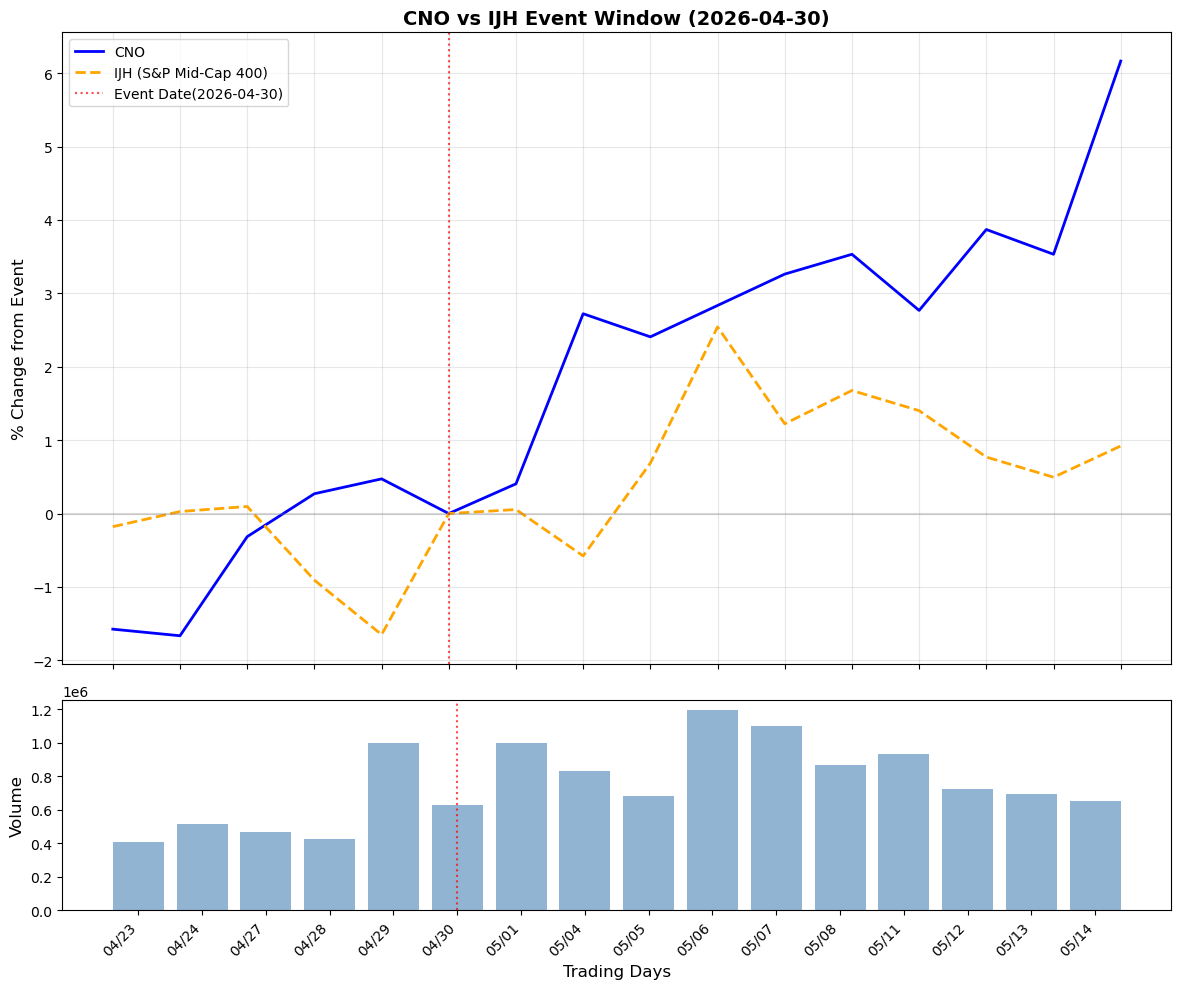

(<Figure size 1200x1000 with 2 Axes>,
 (<Axes: title={'center': 'CNO vs IJH Event Window (2026-04-30)'}, ylabel='% Change from Event'>,
  <Axes: xlabel='Trading Days', ylabel='Volume'>))

In [36]:
plot_event_window('CNO', "2026-04-30")

In [39]:
# =============================================================================
# GATE 2: Institutional Accumulation Volume Footprint
# =============================================================================
# Condition: avg(Vol_T, Vol_T+1, Vol_T+2) / Rolling20D_MA > 2.0

def calc_volume_ratio(row, event_window=3, ma_window=20):
    """
    Compare event-period volume to rolling average before the event.
    Returns the ratio (not boolean).
    """
    ticker = row["ticker"]
    event_dt = row["Date"]

    try:
        stock_full = pd.read_hdf(DB_FILE, f"/sp400/{ticker}")
        stock_full["Date"] = pd.to_datetime(stock_full["Date"])
        stock_full = stock_full.sort_values("Date").reset_index(drop=True)
    except (KeyError, FileNotFoundError):
        return None

    # Find T (event date) index
    t_idx = stock_full[stock_full["Date"] <= event_dt].index
    if len(t_idx) == 0:
        return None
    t_idx = t_idx[-1]

    # Need at least ma_window days before T for the rolling average
    if t_idx < ma_window:
        return None

    # Event window volume average: T to T+(event_window-1)
    event_end_idx = min(t_idx + event_window, len(stock_full))
    event_volumes = stock_full.iloc[t_idx:event_end_idx]["Volume"]
    event_vol_avg = event_volumes.mean()

    # Rolling 20-day volume average ending the day before T
    ma_volumes = stock_full.iloc[t_idx - ma_window : t_idx]["Volume"]
    rolling_vol_avg = ma_volumes.mean()

    if rolling_vol_avg == 0 or pd.isna(rolling_vol_avg):
        return None

    return event_vol_avg / rolling_vol_avg


# Calculate volume ratio for all events
print("Calculating volume ratio (Gate 2) for each event...")
tqdm.pandas(desc="Gate 2")
results["volume_ratio"] = results.apply(calc_volume_ratio, axis=1)

# Drop rows where volume ratio could not be calculated
results = results.dropna(subset=["volume_ratio"])

# Gate 2: Volume Ratio > 2.0
gate2_pass = results[results["volume_ratio"] > 2.0].copy()

print(f"\n{'='*60}")
print(f"  GATE 2 RESULT: Volume Ratio > 2.0")
print(f"{'='*60}")
print(f"  Events analyzed:      {len(results)}")
print(f"  Passing events:        {len(gate2_pass)} / {len(results)}({len(gate2_pass)/len(results)*100:.1f}%)")
print(f"  Mean volume ratio:     {results['volume_ratio'].mean():.2f}x")
print(f"  Mean ratio (passing):  {gate2_pass['volume_ratio'].mean():.2f}x" if len(gate2_pass) > 0
else "  Mean ratio (passing):  N/A")
print(f"{'='*60}")

# Combined Gate 1 + Gate 2
gates_1_2 = results[(results["car_10d"] > 0.03) & (results["volume_ratio"] > 2.0)].copy()

print(f"\n{'='*60}")
print(f"  GATE 1 + GATE 2 (both pass)")
print(f"{'='*60}")
print(f"  Events passing both:    {len(gates_1_2)} / {len(results)}({len(gates_1_2)/len(results)*100:.1f}%)")
print(f"  Mean CAR (both):        {gates_1_2['car_10d'].mean():.2%}")
print(f"  Mean volume ratio (both): {gates_1_2['volume_ratio'].mean():.2f}x")
print(f"{'='*60}")

# Show top events by CAR that also pass both gates
print("\n--- Top 10 by CAR (passing both gates) ---")
top_dual = gates_1_2.nlargest(10, "car_10d")[["Date", "ticker", "car_10d", "volume_ratio"]]
print(top_dual.to_string(index=False))


Calculating volume ratio (Gate 2) for each event...


Exception ignored in: <function tqdm.__del__ at 0x0000028F34758540>
Traceback (most recent call last):
  File "c:\Users\thanh\anaconda3\envs\trading\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\thanh\anaconda3\envs\trading\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'



  GATE 2 RESULT: Volume Ratio > 2.0
  Events analyzed:      1561
  Passing events:        639 / 1561(40.9%)
  Mean volume ratio:     2.10x
  Mean ratio (passing):  2.91x

  GATE 1 + GATE 2 (both pass)
  Events passing both:    194 / 1561(12.4%)
  Mean CAR (both):        7.16%
  Mean volume ratio (both): 3.00x

--- Top 10 by CAR (passing both gates) ---
               Date ticker  car_10d  volume_ratio
2025-11-20 11:55:00   BBWI 0.194774      4.722636
2025-08-27 20:01:00   NTNX 0.190217      3.072762
2025-09-09 20:02:42   AVAV 0.184630      2.738077
2026-01-29 21:05:00    OLN 0.183411      2.159172
2025-08-06 20:05:00    ELF 0.170761      2.910088
2026-04-27 20:08:06   RMBS 0.166648      3.123583
2025-08-07 10:00:00   CELH 0.163375      3.125784
2026-01-28 21:05:00    WHR 0.154866      3.134029
2026-05-05 12:01:13   IPGP 0.149330      3.886895
2025-08-18 20:15:00     FN 0.145830      2.454025


In [47]:
gates_1_2[50:70]

,Date,ticker,eps_estimate,reported_eps,car_10d,car_pct,volume_ratio
368,2025-08-05 20:00:00,CRUS,1.09529,1.5100,0.132889,13.288918,2.850899
370,2026-02-03 21:00:00,CRUS,2.43600,2.9700,0.053855,5.385514,2.496347
372,2025-07-30 20:05:00,CSL,6.62571,6.2700,0.091460,9.146034,2.154501
396,2025-08-06 20:19:29,CXT,0.94673,0.9700,0.035622,3.562242,2.097695
403,2026-05-05 20:06:12,CYTK,-1.64786,-1.6700,0.064695,6.469509,6.243232
417,2025-10-30 10:42:59,DINO,1.86448,2.4400,0.055146,5.514602,2.116611
418,2026-02-18 11:30:00,DINO,0.45245,1.2000,0.136143,13.614341,2.964238
420,2025-08-28 11:00:00,DKS,4.29855,4.3800,0.036059,3.605889,2.683952
421,2025-11-25 12:00:00,DKS,2.70702,2.7800,0.035216,3.521623,3.512380
435,2026-05-13 20:01:00,DOCS,0.28238,0.2600,0.143264,14.326406,5.430140


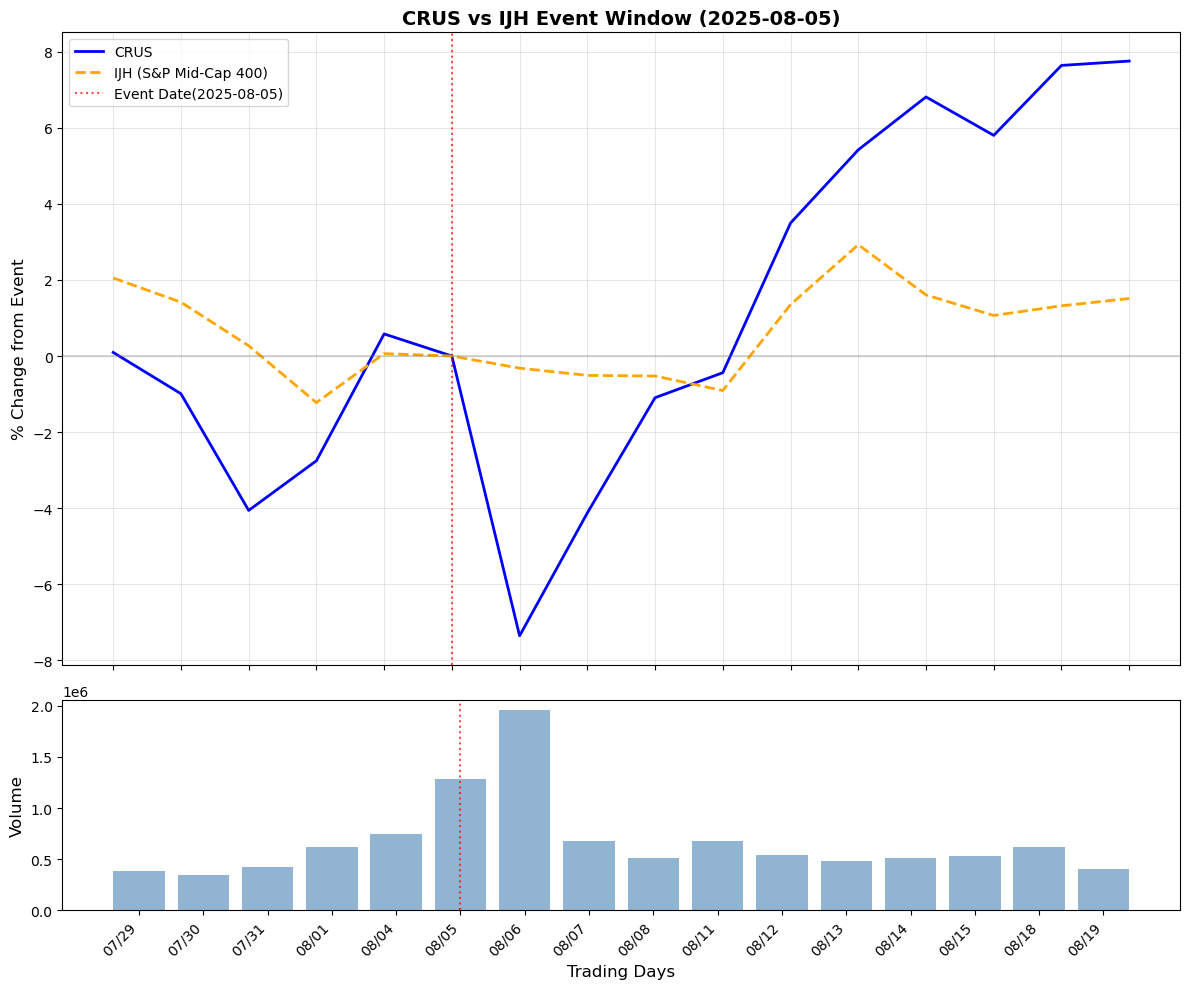

(<Figure size 1200x1000 with 2 Axes>,
 (<Axes: title={'center': 'CRUS vs IJH Event Window (2025-08-05)'}, ylabel='% Change from Event'>,
  <Axes: xlabel='Trading Days', ylabel='Volume'>))

In [48]:
plot_event_window('CRUS', "2025-08-05")

In [ ]:
import pandas as pd
import requests

def fetch_sp400_sector_map():
    """
    Scrapes Wikipedia's S&P MidCap 400 page to map tickers to their GICS Sectors.
    Cleans up tickers to match standard exchange formats used by yfinance/data providers.
    """
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_400_companies"
    
    print("Fetching S&P 400 components and sector metadata from Wikipedia...")
    
    try:
        # pd.read_html scrapes all <table> tags on the page and returns a list of DataFrames
        resp = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
        resp.raise_for_status()
        tables = pd.read_html(resp.content)
        
        # On the S&P 400 page, the main component table is the first table (index 0)
        df = tables[0]
        
        # Force column names to a clean, standardized format
        df.columns = [col.strip().replace(' ', '_').lower() for col in df.columns]
        
        # Filter for the core columns required by your Feature Engineering matrix
        # Wikipedia uses 'ticker_symbol', 'gics_sector', and 'gics_sub-industry'
        keep_cols = ['ticker_symbol', 'security', 'gics_sector', 'gics_sub-industry']
        df = df[keep_cols].rename(columns={
            'ticker_symbol': 'ticker',
            'gics_sector': 'sector',
            'gics_sub-industry': 'sub_industry'
        })
        
        # CRITICAL QUANT CLEANING: 
        # Wikipedia sometimes formats dual-class or complex tickers with dots or dashes (e.g., BRK.B).
        # yfinance expects hyphens or raw strings depending on the corporate structure.
        df['ticker'] = df['ticker'].astype(str).str.strip().str.replace('.', '-', regex=False)
        
        print(f"Successfully scraped {len(df)} tickers with mapped GICS sectors.")
        
        # Preview the metadata lookup dataframe
        print("\n", df.head())
        
        # Save locally as your static database reference lookup
        df.to_csv("sp400_sector_metadata.csv", index=False)
        print("\nSaved metadata reference to 'sp400_sector_metadata.csv'")
        
        return df

    except Exception as e:
        print(f"Network error or Wikipedia structural change detected: {e}")
        return None


sector_lookup_df = fetch_sp400_sector_map()

Fetching S&P 400 components and sector metadata from Wikipedia...
Network error or Wikipedia structural change detected: [Errno 2] No such file or directory: b'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>List of S&amp;P 400 companies - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled 

In [24]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

def fetch_sp400_sector_map_fallback():
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_400_companies"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    
    print("Executing BeautifulSoup explicit extraction layer...")
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    
    # Parse the HTML text structure
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Find the target S&P 400 constituent table by its class
    table = soup.find('table', {'id': 'constituents'})
    if not table:
        # Fallback if ID changed: find the first wikitable
        table = soup.find('table', {'class': 'wikitable'})
        
    rows = []
    # Loop explicitly through table rows to bypass pd.read_html limitations
    for row in table.find_all('tr')[1:]: # Skip the header row
        cols = row.find_all('td')
        if len(cols) >= 5:
            rows.append({
                'ticker': cols[0].text.strip().replace('.', '-', -1),
                'security': cols[1].text.strip(),
                'sector': cols[2].text.strip(),
                'sub_industry': cols[4].text.strip()
            })
            
    df = pd.DataFrame(rows)
    print(f"Extraction stable. Scraped {len(df)} tickers.")
    df.to_csv("sp400_sector_metadata.csv", index=False)
    return df

df = fetch_sp400_sector_map_fallback()

Executing BeautifulSoup explicit extraction layer...
Extraction stable. Scraped 400 tickers.


In [25]:
df

,ticker,security,sector,sub_industry
0,AA,Alcoa,Materials,"Pittsburgh, Pennsylvania"
1,AAL,American Airlines Group,Industrials,"Fort Worth, Texas"
2,AAON,AAON,Industrials,"Tulsa, Oklahoma"
3,ACI,Albertsons,Consumer Staples,"Boise, Idaho"
4,ACM,AECOM,Industrials,"Dallas, Texas"
...,...,...,...,...
395,WWD,"Woodward, Inc.",Industrials,"Fort Collins, Colorado"
396,XPO,"XPO, Inc.",Industrials,"Greenwich, Connecticut"
397,XRAY,Dentsply Sirona,Health Care,"Charlotte, North Carolina"
398,YETI,Yeti Holdings,Consumer Discretionary,"Austin, Texas"


In [5]:
import pandas as pd

df = pd.read_hdf('db.h5','/metadata/sp400')
# df[df.ticker.isin(['ARRS','BTU'])]
# df[df.ticker.isin(['AOS'])]
df 

,ticker,name,gics_sector,gics_sub_industry,intervals
0,AA,Alcoa,Materials,Aluminum,"[{""added"": ""2021-12-20"", ""removed"": null}]"
1,AAL,American Airlines Group,Industrials,Passenger Airlines,"[{""added"": ""2024-09-23"", ""removed"": null}]"
2,AAON,AAON,Industrials,Building Products,"[{""added"": ""2024-05-03"", ""removed"": null}]"
3,AAP,,,,"[{""added"": ""2015-07-08"", ""removed"": ""2015-07-0..."
4,AAXN,,,,"[{""added"": ""2019-07-01"", ""removed"": null}]"
...,...,...,...,...,...
988,YETI,Yeti Holdings,Consumer Discretionary,Leisure Products,"[{""added"": ""2021-01-21"", ""removed"": null}]"
989,ZBRA,,,,"[{""added"": ""2019-12-13"", ""removed"": ""2019-12-1..."
990,ZD,,,,"[{""added"": ""2024-09-23"", ""removed"": ""2024-09-2..."
991,ZI,,,,"[{""added"": ""2023-06-19"", ""removed"": null}]"


In [3]:
import json
from pathlib import Path
import pandas as pd
import requests
from bs4 import BeautifulSoup

DB_FILE = Path("db.h5")
WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_400_companies"

In [4]:
def fetch_changes() -> pd.DataFrame:
    """Fetch historical component changes (Table 2)."""
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
    }
    resp = requests.get(WIKI_URL, headers=headers)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")
    tables = soup.find_all("table", {"class": "wikitable"})
    if len(tables) < 2:
        raise ValueError("Could not find changes table on Wikipedia page")
    table = tables[1]
    rows = []
    current_date = None
    for tr in table.find_all("tr")[2:]:
        cols = tr.find_all("td")
        if not cols:
            continue
        first_rowspan = cols[0].get("rowspan", "1") if cols else "1"
        try:
            rs = int(first_rowspan)
        except (ValueError, TypeError):
            rs = 1
        if rs > 1 or len(cols) >= 6:
            current_date = cols[0].text.strip()
            if len(cols) >= 6:
                rows.append(
                    {
                        "date": current_date,
                        "added_ticker": cols[1].text.strip().replace(".", "-"),
                        "added_security": cols[2].text.strip(),
                        "removed_ticker": cols[3].text.strip().replace(".", "-"),
                        "removed_security": cols[4].text.strip(),
                    }
                )
        elif len(cols) == 4 and current_date:
            rows.append(
                {
                    "date": current_date,
                    "added_ticker": cols[0].text.strip().replace(".", "-"),
                    "added_security": cols[1].text.strip(),
                    "removed_ticker": cols[2].text.strip().replace(".", "-"),
                    "removed_security": cols[3].text.strip(),
                }
            )
        elif len(cols) == 5 and current_date:
            rows.append(
                {
                    "date": current_date,
                    "added_ticker": cols[0].text.strip().replace(".", "-"),
                    "added_security": cols[1].text.strip(),
                    "removed_ticker": cols[2].text.strip().replace(".", "-"),
                    "removed_security": cols[3].text.strip(),
                }
            )
    df = pd.DataFrame(rows)
    df["added_ticker"] = df["added_ticker"].replace("", pd.NA)
    df["removed_ticker"] = df["removed_ticker"].replace("", pd.NA)
    return df


In [5]:
changes = fetch_changes()
print(f" Changes: {len(changes)}")

 Changes: 612


In [7]:

changes["date"] = (
    changes["date"]
    .str.replace(r"\[\d+\]", "", regex=True)
    .str.strip()
)
changes["date"] = pd.to_datetime(changes["date"], errors="coerce")
changes = changes.dropna(subset=["date"])

changes = changes.sort_values("date").reset_index(drop=True)
ticker_intervals = {}

In [8]:
changes

,date,added_ticker,added_security,removed_ticker,removed_security
0,2012-01-13,CRI,Carter's,NDN,99¢ Only Stores
1,2012-02-03,POST,Post Holdings,CRK,Comstock Resources
2,2012-03-26,WXS,Wright Express,SUG,Southern Union
3,2012-04-30,SVU,SUPERVALU,AM,American Greetings
4,2012-05-15,TPX,Tempur-Pedic International,TNB,Thomas & Betts
...,...,...,...,...,...
607,2026-06-22,VIAV,Viavi Solutions,BLKB,Blackbaud
608,2026-06-22,SANM,Sanmina Corporation,CNXC,Concentrix
609,2026-06-22,SMTC,Semtech,COTY,Coty
610,2026-06-22,CDE,Coeur Mining,BRBR,BellRing Brands
